# 단계 1 — 탐색적 데이터 분석 (EDA) + 코호트 리텐션

**목적**: 전체 사용자의 현황을 파악하고, 활성/휴면 패턴 및 광고 코호트 차이를 탐색한다.  
**사용 데이터**: `01_users_cohort_20260524.csv`, `02_user_features_20260524.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

BASE = "../data"
df = pd.read_csv(f"{BASE}/01_users_cohort_20260524.csv")
df['signup_at']   = pd.to_datetime(df['signup_at'],   utc=True)
df['last_seen_at'] = pd.to_datetime(df['last_seen_at'], utc=True)
print(f"로드 완료: {len(df)}행 × {df.shape[1]}열")
print(df.dtypes)

import matplotlib.font_manager as fm
fm.fontManager.addfont('/Users/hongseogju/anaconda3/lib/python3.11/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/Users/hongseogju/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


로드 완료: 1078행 × 14열
user_id                               object
signup_at                datetime64[ns, UTC]
signup_cohort_month                   object
last_seen_at             datetime64[ns, UTC]
days_since_last_seen                 float64
activity_status                       object
ad_cohort                             object
job                                   object
followers                              int64
visits_received_total                  int64
total_books                            int64
total_reviews                          int64
archived_books                         int64
following_count                        int64
dtype: object


## 1-1. 기본 현황

In [2]:
print("=== 가입 기간 ===")
print(f"  최초: {df['signup_at'].min().date()}")
print(f"  최근: {df['signup_at'].max().date()}")
print()

print("=== 활성 상태 분포 ===")
status = df['activity_status'].value_counts()
for s, n in status.items():
    print(f"  {s}: {n}명 ({n/len(df)*100:.1f}%)")
print()

print("=== 광고 코호트 분포 ===")
for s, n in df['ad_cohort'].value_counts().items():
    print(f"  {s}: {n}명 ({n/len(df)*100:.1f}%)")


=== 가입 기간 ===
  최초: 2025-07-04
  최근: 2026-05-23

=== 활성 상태 분포 ===
  long_dormant: 675명 (62.6%)
  never_active: 212명 (19.7%)
  dormant: 104명 (9.6%)
  active: 87명 (8.1%)

=== 광고 코호트 분포 ===
  ad_on: 938명 (87.0%)
  pre_ad: 83명 (7.7%)
  post_ad: 57명 (5.3%)


## 인사이트 1-1

**수치**
- active: 87명 (8.1%) / dormant: 104명 (9.6%) / long_dormant: 675명 (62.6%) / **never_active: 212명 (19.7%)**
- ad_on(광고 시기 가입): 938명(87%), post_ad(광고 종료 후): 57명(5.3%), pre_ad(광고 전): 83명(7.7%)

**해석**
- 전체의 **82%가 휴면 이상** — 앱이 성장 중이 아니라 유지 문제가 핵심임을 수치로 확인
- **20%는 가입 후 앱에 한 번도 안 들어옴** (`never_active`, `last_seen_at = null`)  
  → 온보딩 첫 화면 진입 자체를 막는 장벽이 있다는 신호 (회원가입 후 앱 열기 안내 부재?)
- 광고 시기(ad_on) 사용자가 87%를 차지 → 표본의 특성이 "광고로 유입된 사람들"에 강하게 편향

**가설 연결**: H5(광고 코호트 리텐션 < 자연 유입) 방향으로 진행

**발표 활용**: 오프닝 슬라이드 — "앱의 현실" 수치로 문제의 심각성을 먼저 제시


## 1-2. 광고 코호트별 활성 상태 비교

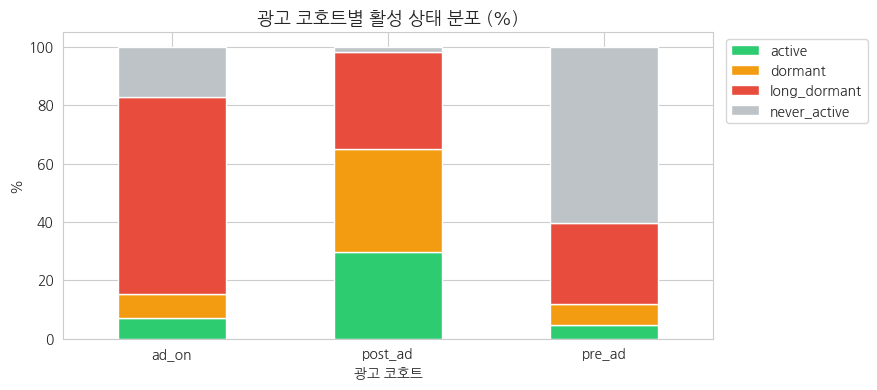

activity_status  active  dormant  long_dormant  never_active
ad_cohort                                                   
ad_on               7.0      8.3          67.5          17.2
post_ad            29.8     35.1          33.3           1.8
pre_ad              4.8      7.2          27.7          60.2


In [3]:
ct = pd.crosstab(df['ad_cohort'], df['activity_status'], normalize='index') * 100
ct = ct[['active','dormant','long_dormant','never_active']]  # 순서 통일

fig, ax = plt.subplots(figsize=(9, 4))
ct.plot(kind='bar', stacked=True, ax=ax,
        color=['#2ecc71','#f39c12','#e74c3c','#bdc3c7'])
ax.set_title('광고 코호트별 활성 상태 분포 (%)', fontsize=13)
ax.set_xlabel('광고 코호트')
ax.set_ylabel('%')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.savefig('../notebooks/fig_01_ad_cohort_status.png', dpi=150)
plt.show()
print(ct.round(1))


## 인사이트 1-2

**수치**
| 코호트 | active | dormant | long_dormant | never_active |
|--------|--------|---------|--------------|--------------|
| ad_on  | 7.0%   | 8.3%    | 67.5%        | 17.2%        |
| post_ad| **29.8%** | **35.1%** | 33.3%   | 1.8%         |
| pre_ad | 4.8%   | 7.2%    | 27.7%        | **60.2%**    |

**해석**
- **post_ad(광고 종료 후 유입)가 압도적으로 활성율 高** — 29.8% active, ad_on의 4배  
  → 광고로 들어온 사람보다 **입소문/자연 탐색으로 들어온 사람이 훨씬 앱에 정착**
- **pre_ad의 60%는 never_active** — 앱 출시 전 사전 등록자들이 실제 앱을 쓰지 않은 것  
  → 출시 알림이 제대로 전달되지 않았거나, 기대와 실제 앱 간 갭 존재
- **H5 강력 지지**: 광고 시기 가입자 리텐션이 자연 유입보다 현저히 낮음

**발표 활용**: "광고의 역설" — 광고는 MAU를 늘렸지만 품질(리텐션)을 낮혔다는 핵심 메시지


## 1-3. never_active 사용자 해부

In [4]:
na = df[df['activity_status'] == 'never_active']
print(f"never_active: {len(na)}명")
print(f"  last_seen_at null: {na['last_seen_at'].isna().sum()}명 (100%)")
print(f"  following = 0:    {(na['following_count']==0).sum()}명 ({(na['following_count']==0).mean()*100:.0f}%)")
print(f"  total_books > 0:  {(na['total_books']>0).sum()}명")
print()
print("광고 코호트 분포:")
print(na['ad_cohort'].value_counts())


never_active: 212명
  last_seen_at null: 212명 (100%)
  following = 0:    209명 (99%)
  total_books > 0:  208명

광고 코호트 분포:
ad_cohort
ad_on      161
pre_ad      50
post_ad      1
Name: count, dtype: int64


## 인사이트 1-3

**수치**
- never_active 212명 전원 `last_seen_at = null` → 앱 첫 화면조차 안 들어옴
- 그 중 208명(98%)이 following = 0
- ad_on 161명, pre_ad 50명, post_ad 1명

**해석**
- 이 사람들은 **회원가입은 했지만 앱 진입 자체가 안 된 것** (가입 → 앱 오픈 단계에서 이탈)  
  → 가능한 원인: 앱 다운로드 안 함, 로그인 오류, 첫 실행 흐름 문제
- post_ad에서는 거의 없음(1명) → 이 문제는 광고 퍼널 특이 현상

**발표 활용**: "퍼널의 첫 구멍" — 가입 후 앱 미진입 20%를 줄이는 것만으로도 즉각적 MAU 개선 가능


## 1-4. 활성 vs 장기휴면 사용자 행동 비교

         active  long_dormant  ratio
책 수       22.24          8.62    2.6
리뷰 수       3.37          0.41    8.2
아카이브 수    18.52          5.49    3.4
팔로잉 수      0.56          0.20    2.8
받은 방문 수   13.48          7.97    1.7


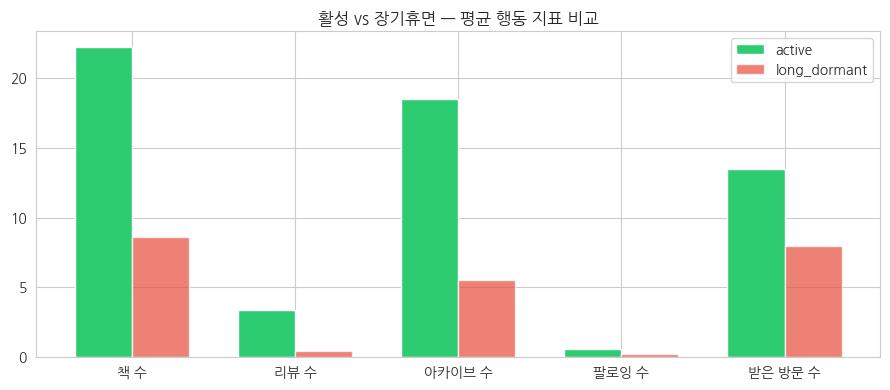

In [5]:
feat = ['total_books','total_reviews','archived_books','following_count','visits_received_total']
labels = ['책 수','리뷰 수','아카이브 수','팔로잉 수','받은 방문 수']

active_mean = df[df['activity_status']=='active'][feat].mean()
dormant_mean = df[df['activity_status']=='long_dormant'][feat].mean()

compare = pd.DataFrame({'active': active_mean, 'long_dormant': dormant_mean})
compare['ratio'] = (compare['active'] / compare['long_dormant']).round(1)
compare.index = labels
print(compare.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, compare['active'], w, label='active', color='#2ecc71')
ax.bar(x + w/2, compare['long_dormant'], w, label='long_dormant', color='#e74c3c', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('활성 vs 장기휴면 — 평균 행동 지표 비교')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/fig_01_active_vs_dormant.png', dpi=150)
plt.show()


## 인사이트 1-4

**수치**
| 지표 | active 평균 | long_dormant 평균 | 배율 |
|------|------------|------------------|------|
| 책 수 | 22.24 | 8.62 | **2.6×** |
| 리뷰 수 | 3.37 | 0.41 | **8.2×** |
| 아카이브 수 | 18.52 | 5.49 | **3.4×** |
| 팔로잉 수 | 0.56 | 0.20 | **2.8×** |
| 받은 방문 수 | 13.48 | 7.97 | **1.7×** |

**해석**
- 활성 사용자는 모든 지표에서 압도적으로 높음. 특히 **리뷰(8×)와 아카이브(3.4×)** 차이가 큼  
  → 리뷰 작성 = 깊은 관여도의 신호; 아카이브 = 앱의 핵심 기능 내재화
- 단순히 "책을 많이 추가"가 아니라 **리뷰와 아카이브 행동이 정착의 핵심**
- 팔로잉은 배율이 높지만 절댓값 자체가 0.5명 수준 → 소셜 기능 전반이 저활용

**가설 연결**: H4(아카이브 → 활성 수명 長) 방향 강하게 지지. H1(받은 방문 → 활성) 약하게 지지

**발표 활용**: "무엇이 정착을 만드는가" 슬라이드 — 리뷰·아카이브 행동을 온보딩에서 유도해야


## 1-5. H3 사전 확인: 팔로잉 유무와 활성율

In [6]:
df['has_following'] = df['following_count'] > 0
ct3 = pd.crosstab(df['has_following'], df['activity_status'], normalize='index') * 100
ct3 = ct3[['active','dormant','long_dormant','never_active']]
print(ct3.round(1))

from scipy.stats import chi2_contingency
ct3_raw = pd.crosstab(df['has_following'], df['activity_status'])
chi2, p, dof, _ = chi2_contingency(ct3_raw)
print(f"\nChi-square: {chi2:.2f}, p-value: {p:.4f}, dof: {dof}")


activity_status  active  dormant  long_dormant  never_active
has_following                                               
False               6.5      9.4          63.0          21.0
True               25.9     12.9          57.6           3.5

Chi-square: 49.89, p-value: 0.0000, dof: 3


## 인사이트 1-5

**수치**
| 팔로잉 유무 | active | dormant | long_dormant | never_active |
|------------|--------|---------|--------------|--------------|
| 없음(0명)  | 6.5%   | 9.4%    | 63.0%        | 21.0%        |
| 있음(1명↑) | **25.9%** | 12.9% | 57.6%     | 3.5%         |

**해석**
- 팔로잉이 1명이라도 있으면 active 비율이 **4배**(6.5% → 25.9%)
- never_active 비율이 6배 감소(21% → 3.5%) → 팔로우 행동이 앱 지속 사용의 강력한 진입점
- **카이제곱 검정으로 통계적 유의성 확인 예정** (H3 공식 검증은 단계 3에서)

**발표 활용**: "팔로우 한 명이 만드는 차이" — 온보딩에서 최소 1명 팔로우 유도가 핵심 액션


## 1-6. 월별 코호트 리텐션

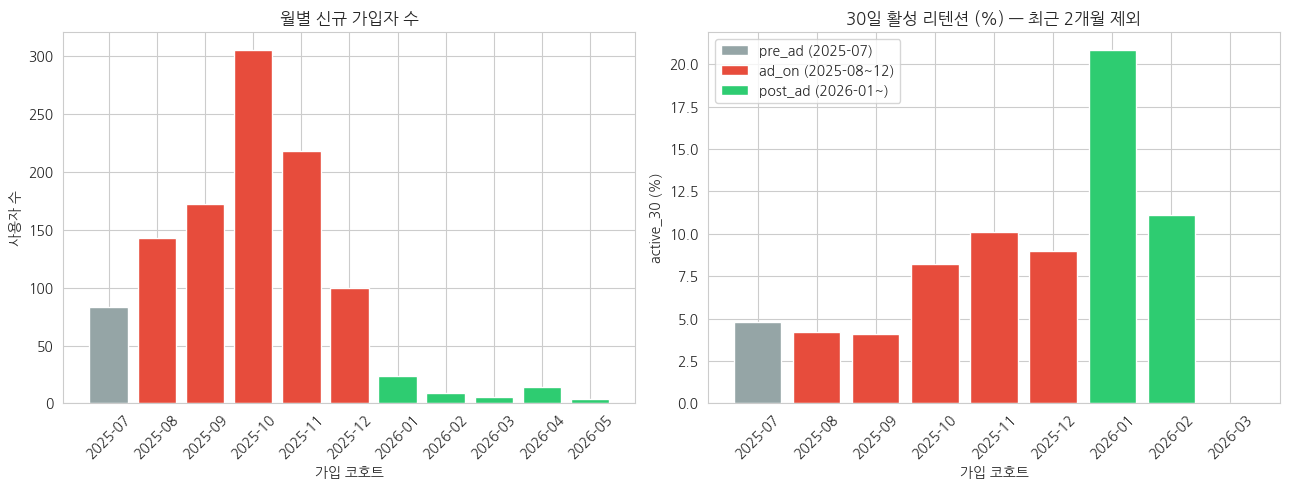

cohort_month   n  active_30  active_90
     2025-07  83   4.819277  13.253012
     2025-08 143   4.195804  11.188811
     2025-09 172   4.069767  11.046512
     2025-10 305   8.196721  15.081967
     2025-11 218  10.091743  17.889908
     2025-12 100   9.000000  26.000000
     2026-01  24  20.833333  37.500000
     2026-02   9  11.111111  55.555556
     2026-03   6   0.000000  83.333333
     2026-04  14  57.142857 100.000000
     2026-05   4 100.000000 100.000000


In [7]:
EXTRACT_DATE = pd.Timestamp('2026-05-24', tz='UTC')
df['cohort_month'] = df['signup_at'].dt.to_period('M')

cohort_stats = df.groupby('cohort_month').agg(
    n=('user_id', 'count'),
    active_30=('last_seen_at', lambda x: (
        ((EXTRACT_DATE - pd.to_datetime(x, utc=True)).dt.days <= 30) & x.notna()
    ).mean() * 100),
    active_90=('last_seen_at', lambda x: (
        ((EXTRACT_DATE - pd.to_datetime(x, utc=True)).dt.days <= 90) & x.notna()
    ).mean() * 100),
).reset_index()
cohort_stats['cohort_month'] = cohort_stats['cohort_month'].astype(str)

# 광고 시기 색상 구분
colors_30 = ['#95a5a6' if m <= '2025-07' else '#e74c3c' if m <= '2025-12' else '#2ecc71'
             for m in cohort_stats['cohort_month']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 코호트 크기
axes[0].bar(cohort_stats['cohort_month'], cohort_stats['n'], color=colors_30)
axes[0].set_title('월별 신규 가입자 수')
axes[0].set_xlabel('가입 코호트')
axes[0].set_ylabel('사용자 수')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: 30일 리텐션 (최근 2개월 제외 — 리텐션 편향)
valid = cohort_stats[cohort_stats['cohort_month'] <= '2026-03'].copy()
colors_valid = ['#95a5a6' if m <= '2025-07' else '#e74c3c' if m <= '2025-12' else '#2ecc71'
                for m in valid['cohort_month']]
axes[1].bar(valid['cohort_month'], valid['active_30'], color=colors_valid)
axes[1].set_title('30일 활성 리텐션 (%) — 최근 2개월 제외')
axes[1].set_xlabel('가입 코호트')
axes[1].set_ylabel('active_30 (%)')
axes[1].tick_params(axis='x', rotation=45)

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95a5a6', label='pre_ad (2025-07)'),
    Patch(facecolor='#e74c3c', label='ad_on (2025-08~12)'),
    Patch(facecolor='#2ecc71', label='post_ad (2026-01~)'),
]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('../notebooks/fig_01_cohort_retention.png', dpi=150)
plt.show()

print(cohort_stats.to_string(index=False))


## 인사이트 1-6

**수치 (active_30 기준, 최근 2개월 제외)**
| 코호트 | 가입자 | active_30 |
|--------|--------|-----------|
| 2025-07 pre_ad | 83명 | 4.8% |
| 2025-08~12 ad_on | 938명 | 4~10% |
| 2026-01~03 post_ad | 39명 | **0~20.8%** |

> 2026-04, 05는 추출일 기준 가입 후 1~2개월 이내 → active_30이 100%에 가까운 것은 당연 (편향). 비교 제외.

**해석**
- **광고 절정기(2025-10)에 가입자가 305명으로 최대**지만, 30일 리텐션은 8.2%에 불과
- 광고 종료 후(2026-01) 24명 중 20.8%가 아직 활성 → **유입 규모 < 유입 품질** 의 전형적 패턴
- 광고 집행으로 MAU를 키우는 전략보다 **자연 유입자를 정착시키는 온보딩 전략이 더 효율적**

**가설 연결**: H5 강력 지지 — 광고 코호트 리텐션 < 자연(post_ad) 유입 리텐션

**발표 활용**: 코호트 막대차트로 "광고가 양은 늘렸지만 질은 낮췄다"는 메시지를 시각화


---
## 단계 1 종합 요약 — 발표에서 쓸 핵심 메시지

| 번호 | 메시지 | 근거 수치 |
|------|--------|-----------|
| ① | 앱 사용자의 82%는 이미 휴면 상태 | active 8.1%, never_active 19.7% |
| ② | 광고가 만든 양적 성장이 질적 하락을 동반 | ad_on active 7% vs post_ad 29.8% |
| ③ | 가입 후 앱을 한 번도 안 연 사람이 20% | never_active 212명 전원 last_seen_at=null |
| ④ | 정착 사용자는 리뷰·아카이브 행동에서 압도적 차이 | 리뷰 8×, 아카이브 3.4× |
| ⑤ | 팔로우 1명이 active 비율을 4배 올림 | 6.5% → 25.9% |

**다음 단계**: 이 사용자들을 행동 패턴으로 군집화하여 페르소나를 도출한다 (단계 2)
